Multi-fidelity Modeling and Experimental Design (Active Learning)

In [1]:
# General imports
import numpy as np
np.random.seed(20)
import pandas as pd
from matplotlib import colors as mcolors
colors = dict(mcolors.BASE_COLORS, **mcolors.CSS4_COLORS)
import sys
import os
sys.path.append('../multi-fidelity-gaussian-process')
import multi_fidelity_surrogate_model as mfsm
import drawing_utils as draw_mfsm
from emukit.multi_fidelity.convert_lists_to_array import convert_x_list_to_array
import random
import math
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [2]:
version = 'vr1.3'
file_in=f'Ge77_rates_CNP_{version}.csv'
if not os.path.exists(f'out/{version}'):
   os.makedirs(f'out/{version}')

# Set parameter name/x_labels -> needs to be consistent with data input file
x_labels=['Radius[cm]','Thickness[cm]','NPanels', 'Theta[deg]', 'Length[cm]']
x_labels_out = ['Radius [cm]','Thickness [cm]','NPanels', 'Angle [deg]', 'Length [cm]']
y_label_cnp = 'Ge-77_CNP'
y_err_label_cnp = 'Ge-77_CNP_err'
y_label_sim = 'rGe77[nuc/(kg*yr)]'

# Set parameter boundaries
xmin=[0,0,0,0,0]
xmax=[265,20,360,90,150]

# Set parameter boundaries for aquisition function
xlow=[90,2,4,0,1]
xhigh=[250,15,360,90,150]

# Assign costs
low_fidelity_cost = 1.
high_fidelity_cost = 2000.

# Set a fixed point in space for drawings
x_fixed = [160, 2, 40, 45, 20]
# number of sigma for error band drawing on prediction
factor=1.

# Get LF noise from file
#with open(f'in/{file_in}') as f:
#    first_line = f.readline()
#LF_noise=np.round(float(first_line.split(' +')[0].split('= ')[1]),3)

# Get HF and LF data samples from file

data=pd.read_csv(f'in/{file_in}')
#data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],y_label_cnp,y_err_label_cnp,y_label_sim]]

LF_noise=np.mean(data.loc[data['Mode']==0.][y_err_label_cnp].to_numpy())
HF_noise=np.mean(data.loc[data['Mode']==1.][y_err_label_cnp].to_numpy())

In [3]:

x_train_l, x_train_h, y_train_l, y_train_h = ([],[],[],[])
row_h=data.index[data['Mode'] == 1].tolist()
row_l=data.index[data['Mode'] == 0].tolist()

x_train_hf_sim = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
y_train_hf_sim = data.loc[data['Mode']==1.][y_label_sim].to_numpy().tolist()

x_train_hf_cnp = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
y_train_hf_cnp = data.loc[data['Mode']==1.][y_label_cnp].to_numpy().tolist()

x_train_lf_cnp = data.loc[data['Mode']==0.0][x_labels].to_numpy().tolist()
y_train_lf_cnp = data.loc[data['Mode']==0.0][y_label_cnp].to_numpy().tolist()

x_train_lf_cnp, x_train_hf_cnp, x_train_hf_sim, y_train_lf_cnp, y_train_hf_cnp, y_train_hf_sim = (np.atleast_2d(x_train_lf_cnp), np.atleast_2d(x_train_hf_cnp), np.atleast_2d(x_train_hf_cnp), np.atleast_2d(y_train_lf_cnp).T, np.atleast_2d(y_train_hf_cnp).T, np.atleast_2d(y_train_hf_sim).T)



In [4]:
%%capture
leg_label = []
ncol=1
nrow=int(np.ceil(len(x_labels)/ncol))
fig1,ax1  = plt.subplots(2,3, figsize=(15, 5), constrained_layout=True)
fig2,ax2  = plt.subplots(nrow,ncol, figsize=(5, 12), constrained_layout=True)

In [5]:

def model_validation(mf_model, file_in, x_labels, y_label, version):
        data=pd.read_csv(file_in)
        #data=data[[f'Mode', x_labels[0], x_labels[1], x_labels[2], x_labels[3], x_labels[4],y_label]]

        x_train_hf_sim = data.loc[data['Mode']==1.][x_labels].to_numpy().tolist()
        y_train_hf_sim = data.loc[data['Mode']==1.][y_label].to_numpy().tolist()
        x_train_hf_sim, y_train_hf_sim = (np.atleast_2d(x_train_hf_sim), np.atleast_2d(y_train_hf_sim).T)

        counter_1sigma = 0
        counter_2sigma = 0
        counter_3sigma = 0
        MAE=0
        MSE=0
        NMSE=0
        MSSE=0

        mfsm_model_mean = np.empty(shape=[0, 0])
        mfsm_model_std = np.empty(shape=[0, 0])
        hf_data=[]
        x=[]
        for i in range(len(x_train_hf_sim)):

                SPLIT = 1
                x_plot = (np.atleast_2d(x_train_hf_sim[i]))
                X_plot = convert_x_list_to_array([x_plot , x_plot, x_plot])
                hhf_mean_mf_model, hhf_var_mf_model = mf_model.predict(X_plot[2*SPLIT:])
                hhf_std_mf_model = np.sqrt(hhf_var_mf_model)

                hf_data.append(y_train_hf_sim[i])
                x.append(i)
                mfsm_model_mean=np.append(mfsm_model_mean,hhf_mean_mf_model[0,0])
                mfsm_model_std=np.append(mfsm_model_std,hhf_std_mf_model[0,0])
                if (y_train_hf_sim[i] < hhf_mean_mf_model+hhf_std_mf_model) and (y_train_hf_sim[i] > hhf_mean_mf_model-hhf_std_mf_model):
                        counter_1sigma += 1
                if (y_train_hf_sim[i] < hhf_mean_mf_model+2*hhf_std_mf_model) and (y_train_hf_sim[i] > hhf_mean_mf_model-2*hhf_std_mf_model):
                        counter_2sigma += 1
                if (y_train_hf_sim[i] < hhf_mean_mf_model+3*hhf_std_mf_model) and (y_train_hf_sim[i] > hhf_mean_mf_model-3*hhf_std_mf_model):
                        counter_3sigma += 1

                MAE +=np.abs(y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0])
                MSE +=pow(y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0],2)
                NMSE +=np.abs((y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0])/hhf_std_mf_model[0][0])
                MSSE +=pow((y_train_hf_sim[i][0]-hhf_mean_mf_model[0][0])/hhf_std_mf_model[0][0],2)
        print("1 sigma: ", counter_1sigma/len(hf_data)*100.," %" )
        print("2 sigma: ", counter_2sigma/len(hf_data)*100.," %" )
        print("3 sigma: ", counter_3sigma/len(hf_data)*100.," %" )
        percentage_1sigma=counter_1sigma/len(hf_data)*100.
        percentage_2sigma=counter_2sigma/len(hf_data)*100.
        percentage_3sigma=counter_3sigma/len(hf_data)*100.

        fig = plt.subplots(figsize=(12, 2.5))
        #plt.bar(x=np.arange(len(mfsm_model_mean)), height=mfsm_model_mean, color="lightgray", label='RESuM')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-3*mfsm_model_std, y2=mfsm_model_mean+3*mfsm_model_std, color="coral",alpha=0.2, label=r'$\pm 3\sigma$')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-2*mfsm_model_std, y2=mfsm_model_mean+2*mfsm_model_std, color="yellow",alpha=0.2, label=r'$\pm 2\sigma$')
        plt.fill_between(x=np.arange(len(mfsm_model_mean)), y1=mfsm_model_mean-mfsm_model_std, y2=mfsm_model_mean+mfsm_model_std, color="green",alpha=0.2, label=r'RESuM $\pm 1\sigma$')
        plt.xlabel('HF Simulation Trial Number')
        plt.ylim(0.,0.55)
        plt.ylabel(r'$y_{raw}$')
        plt.plot(x[:],hf_data[:],'.',color="black", label="HF Validation Data")
        handles, labels = plt.gca().get_legend_handles_labels()
        order = [3,2,1,0]
        plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc=9, bbox_to_anchor=(0.665,1.),ncol=5)
        plt.savefig(f'out/{version}/model-validation_{version}.pdf')
        mse = mean_squared_error(hf_data,mfsm_model_mean, squared=True)
        print("mse: ",mse)
        MAE=MAE/len(x_train_hf_sim)
        mse = mean_squared_error(hf_data,mfsm_model_mean, squared=True)
        NMSE=NMSE/len(x_train_hf_sim)
        MSSE=MSSE/len(x_train_hf_sim)
        return [percentage_1sigma,percentage_2sigma,percentage_3sigma,MSE,NMSE,mse,MSSE]

 /Users/aschuetz/.local/modules/miniconda/miniconda3/envs/legend/lib/python3.10/site-packages/paramz/transformations.py:111: RuntimeWarning:divide by zero encountered in log


1 sigma:  75.0  %
2 sigma:  98.0  %
3 sigma:  100.0  %
mse:  0.0033415444633336784


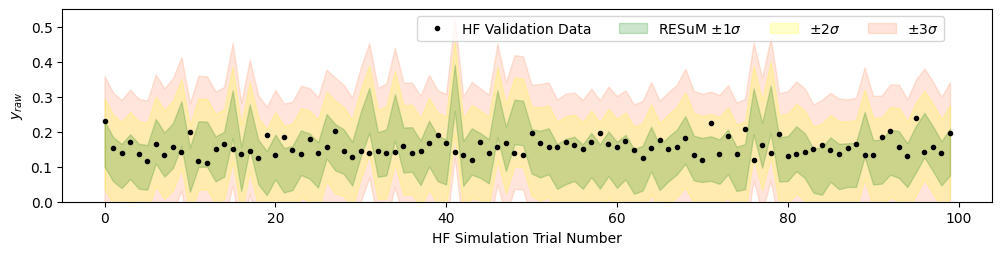

In [6]:

nrestarts=1
mf_model = mfsm.linear_multi_fidelity_model(x_train_lf_cnp, y_train_lf_cnp, LF_noise, x_train_hf_cnp, y_train_hf_cnp, HF_noise, x_train_hf_sim, y_train_hf_sim, nrestarts)
# run the model drawing
#draw_mfsm.draw_model(mf_model, xmin, xmax, x_labels_out, factor, version)#
mean=model_validation(mf_model,"./in/hf_validation_data_v1.2.csv",x_labels, y_label_sim, version)



In [7]:
np.set_printoptions(suppress=True, precision=4)
print(mean)

[75.0, 98.0, 100.0, 0.3341544463333678, 0.7077466492140455, 0.0033415444633336784, 0.7988623010095062]


In [8]:
# Open a file in write mode
with open(f"out/{version}/latex_table_{version}.tex", "w") as file:
    # Write the LaTeX document header
    file.write("\\documentclass{article}\n")
    file.write("\\usepackage{booktabs}\n")
    file.write("\\usepackage{adjustbox}\n")
    file.write("\\begin{document}\n")
    file.write("\\begin{table}[ht]\n")
    file.write("\\centering\n")
    file.write("\\resizebox{\\textwidth}{!}{\n")
    file.write("\\begin{tabular}{|c|c|c|c|c|c|c|c|c|c|c|}\n")
    file.write("\\hline\n")
    file.write("Model & no. HF & no. LF & $1\sigma$ & $1\sigma$ & $3\sigma$ & MAE & NMSE & MSE & MSSE & CPUh\\\\ \\hline\n")

    # Write each row of the table
    file.write(f"RESuM & {300+len(y_train_hf_sim)}&{len(y_train_hf_sim)} & {''.join([f'{x:.4f} & ' for x in mean])} \\\ \hline\n")

    # Write the LaTeX document footer
    file.write("\\end{tabular}\n")
    file.write("}\n")
    file.write("\\caption{MF-BNN}\n")
    file.write("\\label{tab:example}\n")
    file.write("\\end{table}\n")
    file.write("\\end{document}\n")